In [2]:
pip install EMD-signal

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import PyEMD
print(PyEMD.__version__)

1.6.4


In [4]:
import matplotlib.pyplot as plt
# 导入matplotlib的pyplot模块，用于数据可视化。
import tensorflow as tf
# 导入tensorflow库，用于深度学习模型的构建和训练
from PyEMD import EMD, EEMD, CEEMDAN
# 从pyemd库导入EMD, EEMD, CEEMDAN，用于模态分解
import pandas as pd
# 导入pandas库，用于数据处理和分析
import warnings
# 导入warnings库，用于控制警告消息
warnings.filterwarnings("ignore")

C:\Users\111\PycharmProjects\PythonProject1\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\111\PycharmProjects\PythonProject1\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\111\PycharmProjects\PythonProject1\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_han

In [5]:
gpus = tf.config.experimental.list_physical_devices(device_type='GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [6]:
# 用来正常显示中文/英文标签（保持与模板一致）
plt.rcParams['font.sans-serif'] = ['Times New Roman']
# 用来正常显示负号
plt.rcParams['axes.unicode_minus'] = False

In [7]:
df_raw_data = pd.read_csv('THAILAND-FloodPrediction.csv')

# 确保时间列为Datetime并按时间排序
df_raw_data['Month'] = pd.to_datetime(df_raw_data['Month'])
df_raw_data = df_raw_data.sort_values('Month').reset_index(drop=True)

# 只分解目标 rx5day（推荐做法）
series_close = pd.Series(
    df_raw_data['rx5day'].astype(float).values,
    index=df_raw_data['Month']
)
# 创建一个pandas的Series对象。
# df_raw_data['rx5day'].values提取'rx5day'列的值作为Series的数据。
# index=df_raw_data['Month']设置Series的索引为时间戳（YYYY-MM）
print(series_close)

Month
1950-01-01      5.62
1950-02-01      7.10
1950-03-01     25.96
1950-04-01     35.65
1950-05-01     51.54
               ...  
2023-08-01     75.61
2023-09-01    120.18
2023-10-01     85.63
2023-11-01     36.97
2023-12-01     14.90
Length: 888, dtype: float64


In [8]:
def ceemdan_decompose(series=None, trials=100):
    # 定义CEEMDAN分解函数。
    # series: 待分解的时间序列数据。
    # trials: CEEMDAN的试验次数，用于生成噪声。

    decom = CEEMDAN()
    # 创建CEEMDAN对象。

    decom.trials = trials
    # 设置CEEMDAN对象的试验次数。

    df_ceemdan = pd.DataFrame(decom(series.values).T)
    # 对时间序列数据执行CEEMDAN分解，并将结果转置后转换为DataFrame。

    df_ceemdan.columns = ['imf' + str(i+1) for i in range(len(df_ceemdan.columns))]
    # 为DataFrame的每一列命名，表示每个内在模态函数（IMF）。

    return df_ceemdan
    # 返回分解结果的DataFrame。

In [9]:
df_ceemdan = ceemdan_decompose(series_close)
# 对series_close进行CEEMDAN分解，并返回结果的DataFrame。

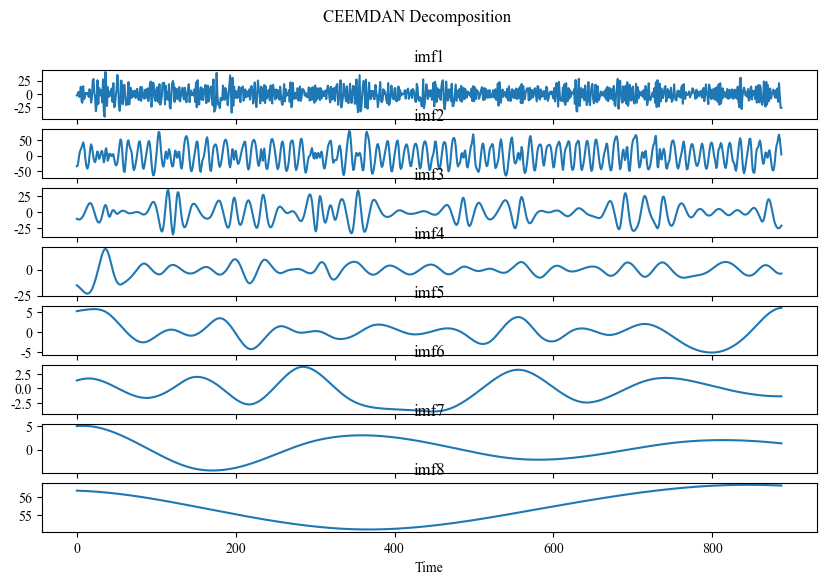

In [10]:
# 可视化VMD分解结果
fig, axs = plt.subplots(nrows=len(df_ceemdan.columns), figsize=(10, 6), sharex=True)
# 创建一个绘图对象和多个子图对象。
for i, col in enumerate(df_ceemdan.columns):
    axs[i].plot(df_ceemdan[col])
    axs[i].set_title(col)
    # 遍历每个模态并绘制在子图上。

plt.suptitle('CEEMDAN Decomposition')
# 设置图表的总标题。

plt.xlabel('Time')
# 设置x轴的标签。

plt.show()
# 显示图表。

In [11]:
print(df_ceemdan)
df_ceemdan.to_excel("CEEMDAN-THAILAND-RX5DAY.xlsx",index=False)
#保存数据为CEEMDAN-THAILAND-RX5DAY.xlsx

          imf1       imf2       imf3       imf4      imf5      imf6      imf7  \
0    -2.984174 -34.069277 -10.164111 -15.034935  5.156264  1.353827  5.027957   
1    -1.613425 -32.888694 -10.753516 -15.610871  5.196602  1.394993  5.041760   
2     3.665879 -18.411818 -11.117957 -16.230492  5.235058  1.433844  5.053712   
3    -5.812089   1.422101 -11.194331 -16.901803  5.271705  1.470308  5.063795   
4    -1.527936  13.408454 -10.922882 -17.629324  5.306614  1.504313  5.071989   
..         ...        ...        ...        ...       ...       ...       ...   
883 -14.862497  56.555225 -25.054232  -3.519941  5.842873 -1.386487  1.418777   
884  19.996456  66.382691 -24.969390  -3.750601  5.891664 -1.386906  1.401508   
885  -1.986770  53.141338 -24.215689  -3.848996  5.929891 -1.386633  1.384025   
886 -26.100364  27.203692 -22.859507  -3.822865  5.957325 -1.385662  1.366331   
887 -26.157872   3.163121 -20.969738  -3.683276  5.974103 -1.383990  1.348428   

          imf8  
0    56.33